# Setup


In [8]:
import numpy as np
import cv2

import PIL.Image as Image
import os

import matplotlib.pylab as plt

import sys
!{sys.executable} -m pip install tensorflow-hub tf-keras

import tensorflow as tf
import tensorflow_hub as hub

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

  Using cached tensorflow_hub-0.16.1-py2.py3-none-any.whl.metadata (1.3 kB)
  Using cached tf_keras-2.21.0-py3-none-any.whl.metadata (1.8 kB)
Using cached tensorflow_hub-0.16.1-py2.py3-none-any.whl (30 kB)
Using cached tf_keras-2.21.0-py3-none-any.whl (1.7 MB)



In [9]:
IMAGE_SHAPE = (224,224)

base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMAGE_SHAPE + (3,),
    include_top=True,
    weights='imagenet'
)

classifier = tf.keras.Sequential([base_model])

14536120/14536120 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [10]:
#from google.colab import drive
import pathlib

#drive.mount('/content/drive')
data_dir = pathlib.Path("data")

# Read images into numpy

In [11]:
class_names = sorted([d.name for d in data_dir.iterdir() if d.is_dir()])

bricks_images_dict = {cls: list(data_dir.glob(f'{cls}/*')) for cls in class_names}

bricks_labels_dict = {cls: idx for idx, cls in enumerate(class_names)}

In [12]:
str(bricks_images_dict['#2341'][0])

'data\\#2341\\file100.png'

In [13]:
img = cv2.imread(str(bricks_images_dict['#2341'][0]))
img.shape

(337, 600, 3)

In [14]:
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm

def load_image(args):
    brick_name, image_path = args
    img = cv2.imread(str(image_path))
    if img is None:
        return None, None
    resized = cv2.resize(img, IMAGE_SHAPE)
    return resized, bricks_labels_dict[brick_name]

tasks = [
    (brick_name, image)
    for brick_name, images in bricks_images_dict.items()
    for image in images
]

X, y = [], []

with ThreadPoolExecutor(max_workers=4) as executor:
    results = list(tqdm(executor.map(load_image, tasks), total=len(tasks)))

for img, label in results:
    if img is not None:
        X.append(img)
        y.append(label)

X = np.array(X)
y = np.array(y)

100%|██████████| 7504/7504 [01:07<00:00, 111.75it/s]


In [16]:
X = np.array(X, dtype=np.uint8)
y = np.array(y)

In [22]:
!"{sys.executable}" -m pip install scikit-learn

     ---------------------------------------- 0.0/61.0 kB ? eta -:--:--
     ---------------------------------------- 61.0/61.0 kB 1.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
    --------------------------------------- 0.2/8.0 MB 3.5 MB/s eta 0:00:03
   --- ------------------------------------ 0.7/8.0 MB 7.5 MB/s eta 0:00:01
   -------- ------------------------------- 1.7/8.0 MB 13.4 MB/s eta 0:00:01
   ------------------- -------------------- 3.8/8.0 MB 22.1 MB/s eta 0:00:01
   ---------------------------------- ----- 6.9/8.0 MB 31.6 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 30.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/309.1 kB ? eta -:--:--
   --------------------------------------- 309.1/309.1 kB 19.9 MB/s eta 0:00:00
   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
   --- ------------------------------------ 3.0/36.5 MB 95.1 MB/s eta 0:00:01
   ------ ----------

In [23]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [24]:
X_train_scaled = X_train.astype(np.float32) / 255.0
del X_train

X_test_scaled = X_test.astype(np.float32) / 255.0
del X_test

In [25]:
X[0].shape

(224, 224, 3)

In [26]:
IMAGE_SHAPE+(3,)

(224, 224, 3)

In [27]:
x0_resized = cv2.resize(X[0], IMAGE_SHAPE)
x1_resized = cv2.resize(X[1], IMAGE_SHAPE)
x2_resized = cv2.resize(X[2], IMAGE_SHAPE)

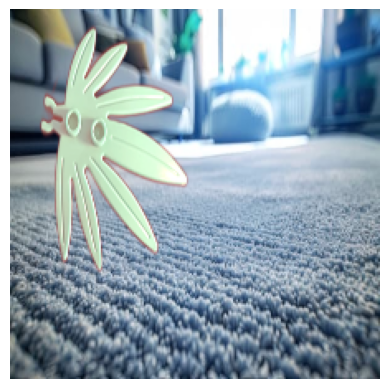

In [28]:
plt.axis('off')
plt.imshow(X[0])

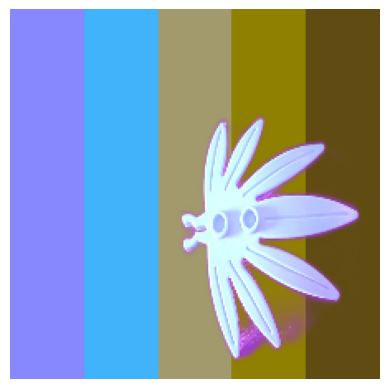

In [29]:
plt.axis('off')
plt.imshow(X[1])

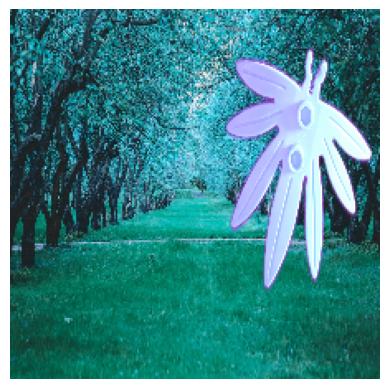

In [30]:
plt.axis('off')
plt.imshow(X[2])

In [31]:
predicted = classifier.predict(np.array([x0_resized, x1_resized, x2_resized]))
predicted = np.argmax(predicted, axis=1)
predicted

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


array([794, 794, 794])

In [32]:
feature_extractor_model = "https://tfhub.dev/google/tf2-preview/mobilenet_v2/feature_vector/4"

In [33]:
pretrained_model_without_top_layer = hub.KerasLayer(
    feature_extractor_model, input_shape=(224, 224, 3), trainable=False)

In [35]:
num_of_bricks = 50

class HubLayerWrapper(keras.Layer):
    def __init__(self, hub_layer, **kwargs):
        super().__init__(**kwargs)
        self.hub_layer = hub_layer

    def call(self, inputs):
        return self.hub_layer(inputs)

wrapped = HubLayerWrapper(pretrained_model_without_top_layer)

model = tf.keras.Sequential([
    wrapped,
    tf.keras.layers.Dense(num_of_bricks)
])

In [36]:
model.compile(
  optimizer="adam",
  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
  metrics=['acc'])

model.fit(X_train_scaled, y_train, epochs=5)

Epoch 1/5



176/176 ━━━━━━━━━━━━━━━━━━━━ 61s 331ms/step - acc: 0.2923 - loss: 2.9249
Epoch 2/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 52s 294ms/step - acc: 0.5650 - loss: 1.7332
Epoch 3/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 50s 284ms/step - acc: 0.6645 - loss: 1.3437
Epoch 4/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 49s 281ms/step - acc: 0.7200 - loss: 1.1075
Epoch 5/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 50s 281ms/step - acc: 0.7655 - loss: 0.9446


In [37]:
model.evaluate(X_test_scaled,y_test)

59/59 ━━━━━━━━━━━━━━━━━━━━ 17s 283ms/step - acc: 0.5949 - loss: 1.5069


[1.506949782371521, 0.5948827266693115]